# Proyecto de Regresión Lineal

In [40]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pickle

## Analisis (EDA)

Planteamiento del problema y recoleccion de datos

Predecir el coste del seguro médico de una persona

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de datos los fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.


    age. Edad del beneficiario principal (numérico)
    sex. Género del beneficiario principal (categórico)
    bmi. índice de masa corporal (numérico)
    children. Número de niños/dependientes cubiertos por un seguro médico (numérico)
    smoker. ¿Es fumador? (categórico)
    region. Área residencial del beneficiario en USA: noreste, sureste, suroeste, noroeste (categórico)
    charges. Prima del seguro médico (numérico)


In [2]:
data = '../data/raw/medical_insurance_cost.csv'

df = pd.read_csv(data, sep=',')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_test = pd.read_csv(data, sep=',')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
duplicados = df[df.duplicated()]
duplicados


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df.drop_duplicates(inplace=True)

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Analisis de Variables

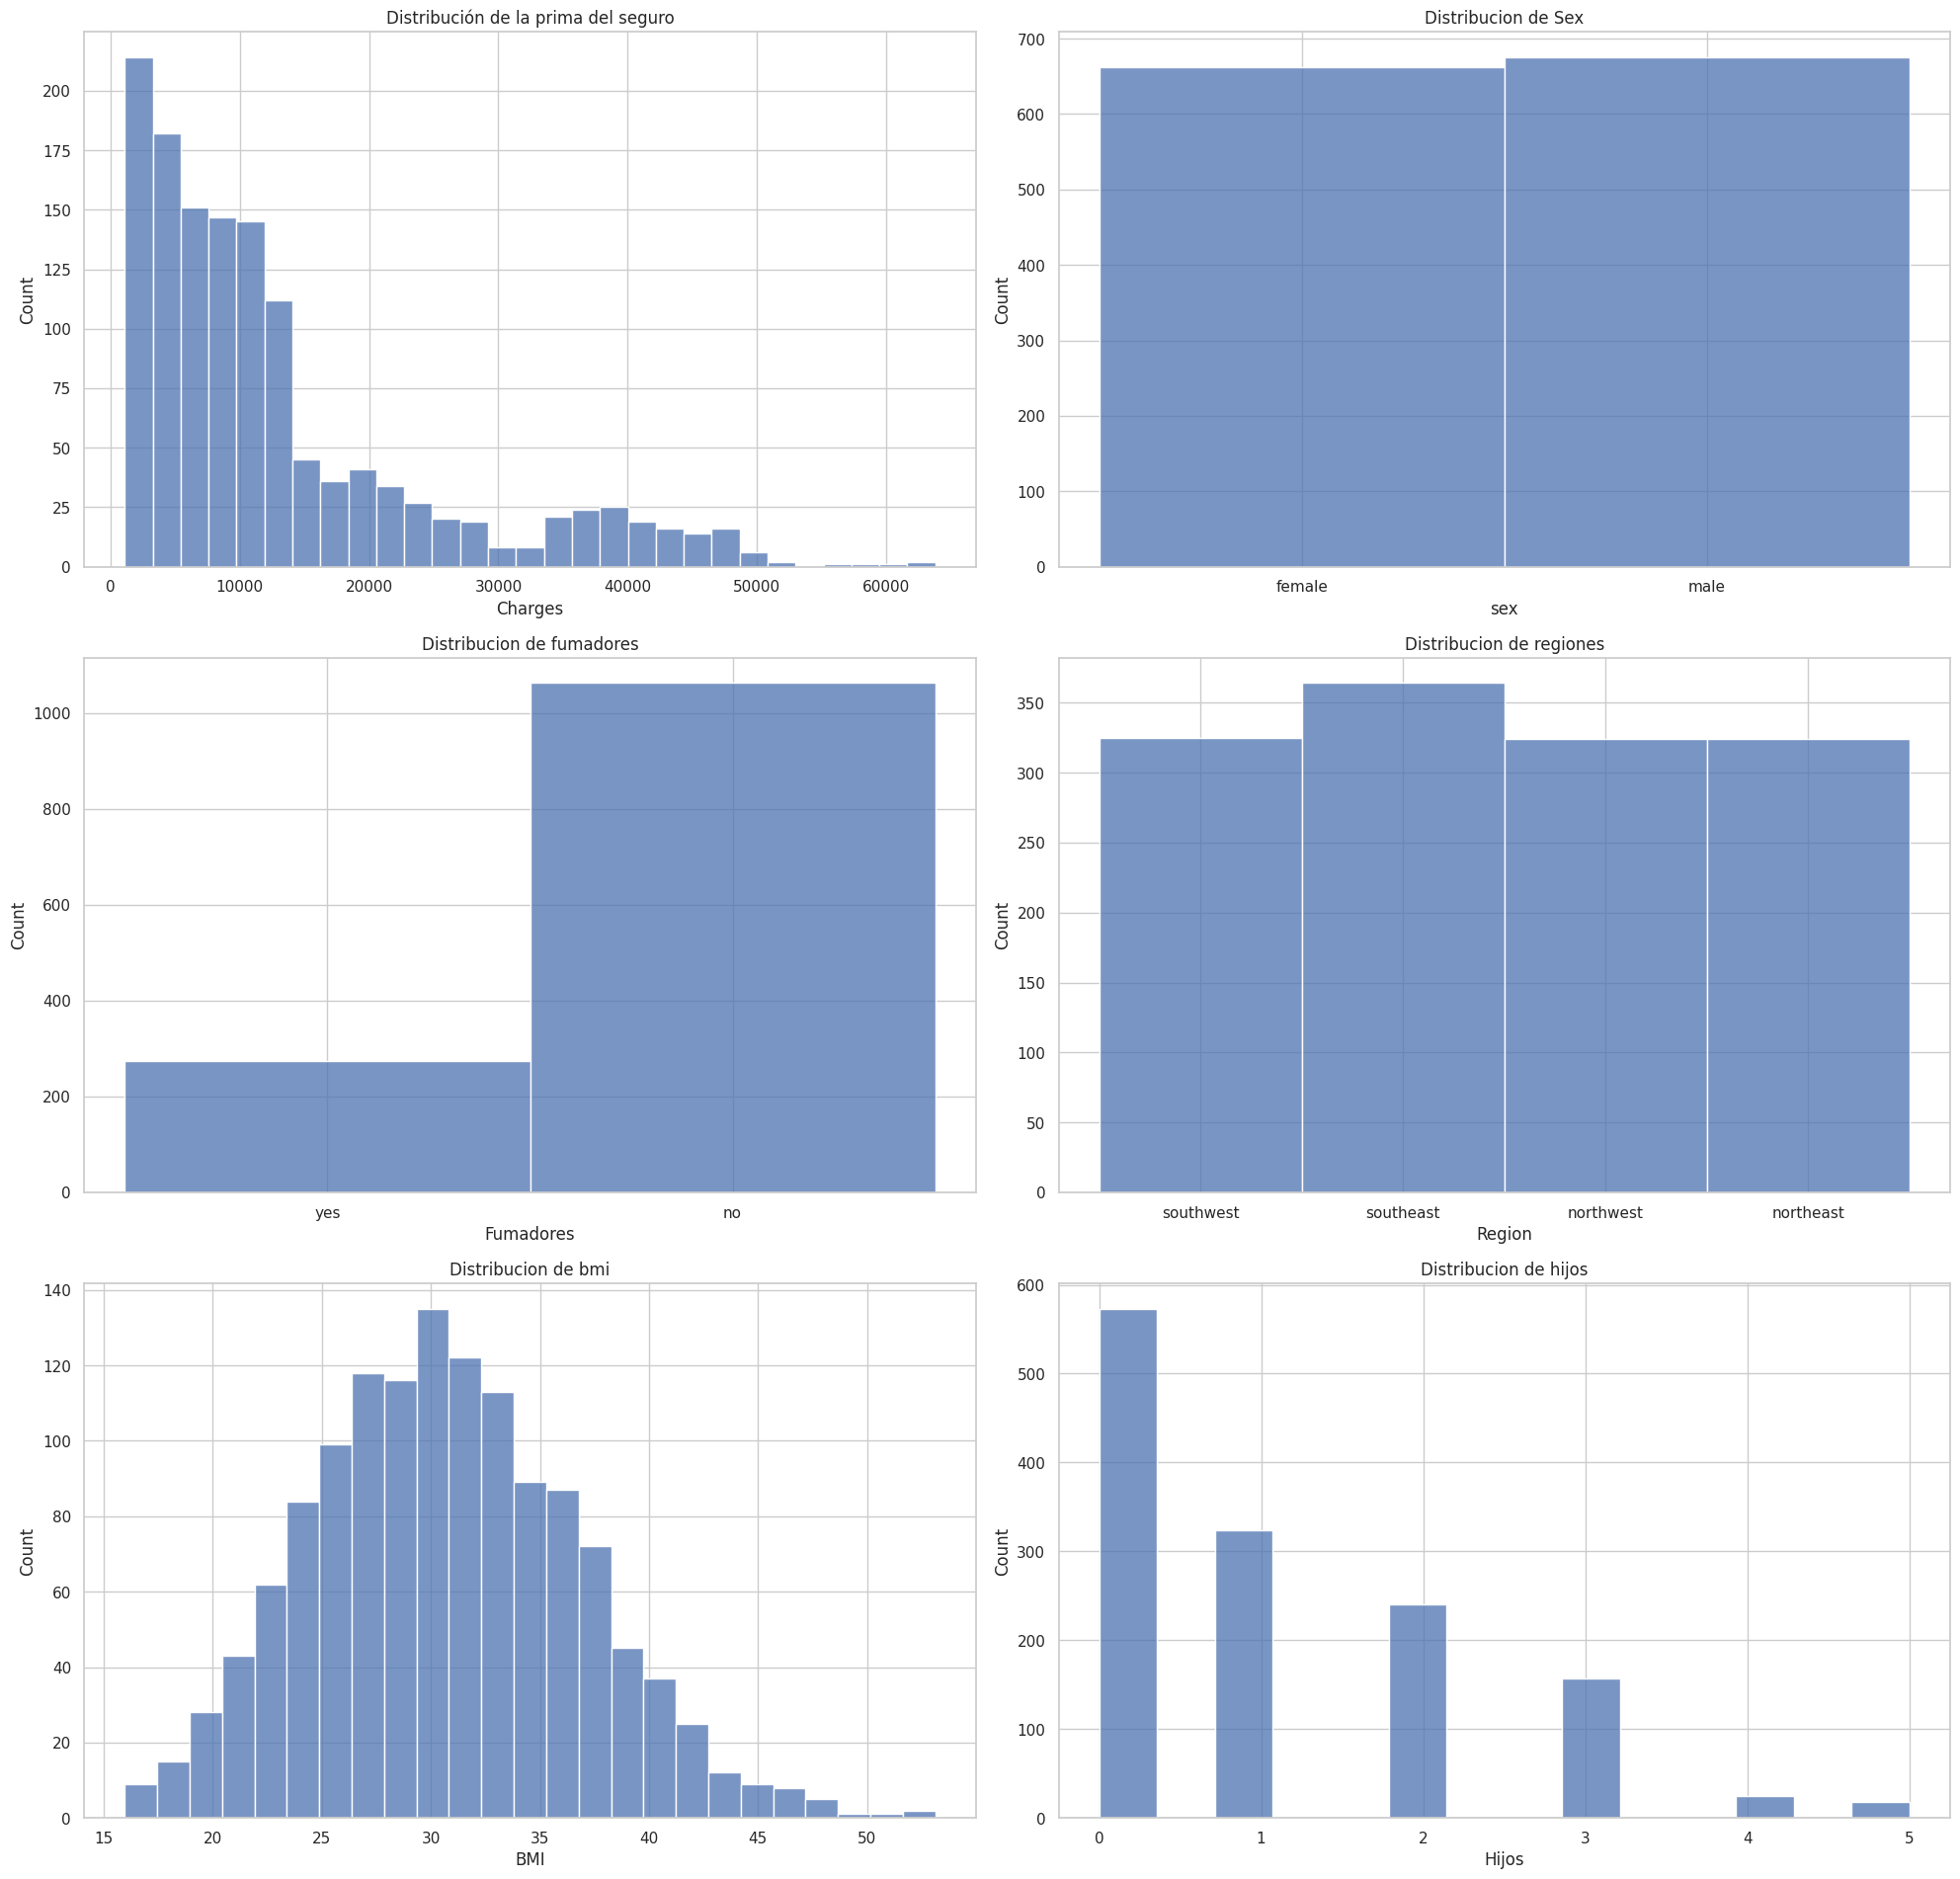

In [9]:

sns.set(style="whitegrid")
plt.figure(figsize=(20, 25))

plt.subplot(4, 2, 1)
sns.histplot(df['charges'])
plt.title('Distribución de la prima del seguro')
plt.xlabel('Charges')

plt.subplot(4, 2, 2)
sns.histplot(df['sex'])
plt.title('Distribucion de Sex')
plt.xlabel('sex')

plt.subplot(4, 2, 3)
sns.histplot(df['smoker'])
plt.title('Distribucion de fumadores')
plt.xlabel('Fumadores')

plt.subplot(4, 2, 4)
sns.histplot(df['region'])
plt.title('Distribucion de regiones')
plt.xlabel('Region')

plt.subplot(4, 2, 5)
sns.histplot(df['bmi'])
plt.title('Distribucion de bmi')
plt.xlabel('BMI')

plt.subplot(4, 2, 6)
sns.histplot(df['children'])
plt.title('Distribucion de hijos')
plt.xlabel('Hijos')


plt.tight_layout()
plt.show()

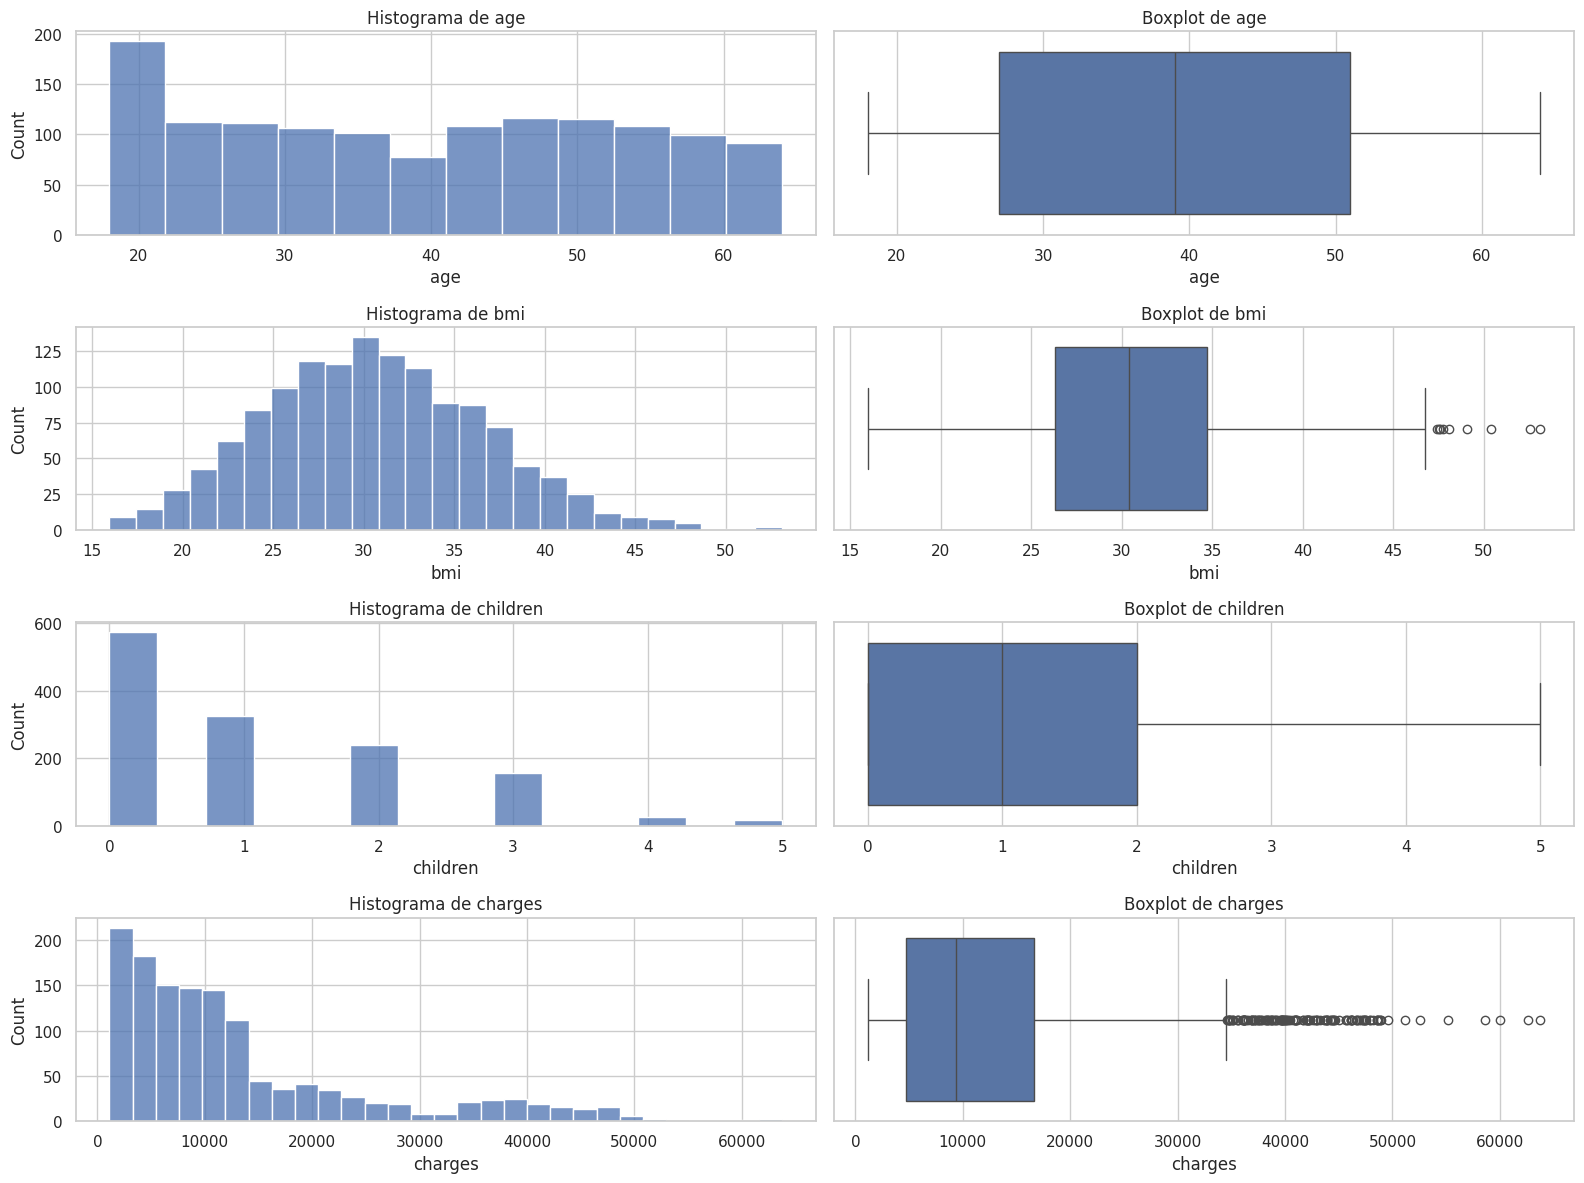

In [10]:
sns.set(style='whitegrid')
plt.figure(figsize=(16, 12))


plt.subplot(4, 2, 1)
sns.histplot(df['age'])
plt.title('Histograma de age')

plt.subplot(4, 2, 2)
sns.boxplot(x=df['age'])
plt.title('Boxplot de age')


plt.subplot(4, 2, 3)
sns.histplot(df['bmi'])
plt.title('Histograma de bmi')

plt.subplot(4, 2, 4)
sns.boxplot(x=df['bmi'])
plt.title('Boxplot de bmi')


plt.subplot(4, 2, 5)
sns.histplot(df['children'])
plt.title('Histograma de children')

plt.subplot(4, 2, 6)
sns.boxplot(x=df['children'])
plt.title('Boxplot de children')


plt.subplot(4, 2, 7)
sns.histplot(df['charges'])
plt.title('Histograma de charges')

plt.subplot(4, 2, 8)
sns.boxplot(x=df['charges'])
plt.title('Boxplot de charges')

plt.tight_layout()
plt.show()

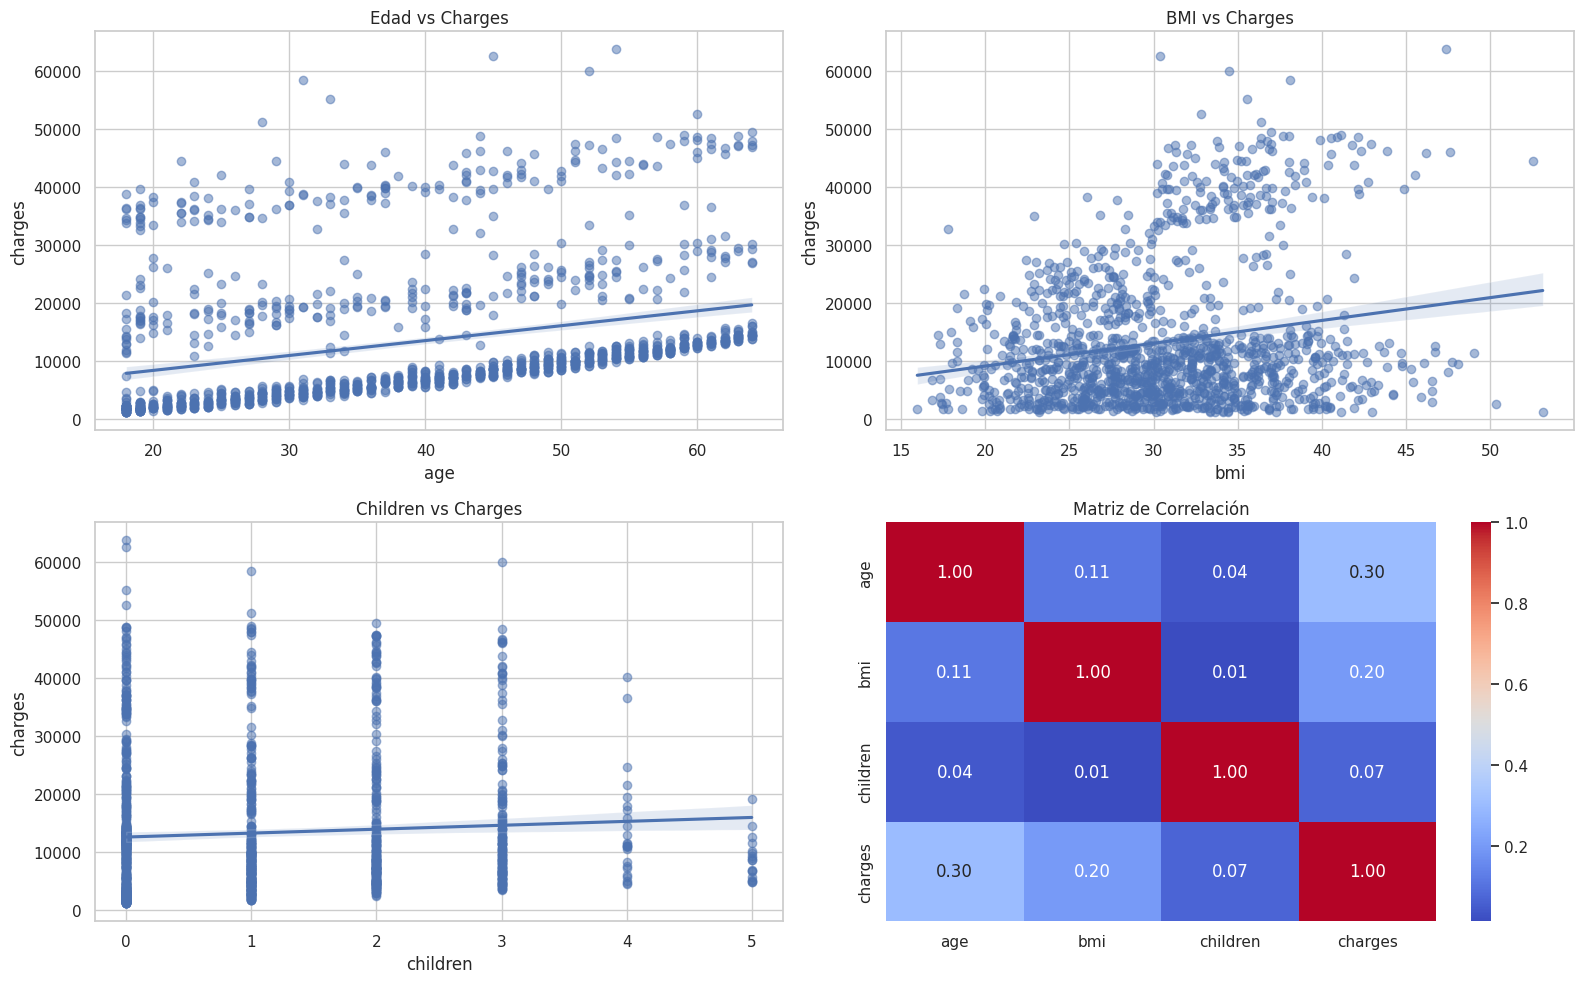

In [11]:

sns.set(style='whitegrid')
plt.figure(figsize=(16, 10))


plt.subplot(2, 2, 1)
sns.regplot(x='age', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('Edad vs Charges')


plt.subplot(2, 2, 2)
sns.regplot(x='bmi', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('BMI vs Charges')


plt.subplot(2, 2, 3)
sns.regplot(x='children', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('Children vs Charges')


plt.subplot(2, 2, 4)
correlation = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')

plt.tight_layout()
plt.show()


### Cambiar las categoricas a numericas para poder comparar

Las columnas categoricas son Sex, Smoker y Region

In [12]:
df["sex_n"] = pd.factorize(df["sex"])[0] # 0 female 1 male
df["smoker_n"] = pd.factorize(df["smoker"])[0] # 0 fumador 1 no fumador
df["region_n"] = pd.factorize(df["region"])[0] # 0 southwest 1 southeast 2 northwest 3 northeast

df

,age,sex,bmi,children,smoker,region,charges,sex_n,smoker_n,region_n
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0
1,18,male,33.770,1,no,southeast,1725.55230,1,1,1
2,28,male,33.000,3,no,southeast,4449.46200,1,1,1
3,33,male,22.705,0,no,northwest,21984.47061,1,1,2
4,32,male,28.880,0,no,northwest,3866.85520,1,1,2
...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,1,1,2
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,3
1335,18,female,36.850,0,no,southeast,1629.83350,0,1,1
1336,21,female,25.800,0,no,southwest,2007.94500,0,1,0


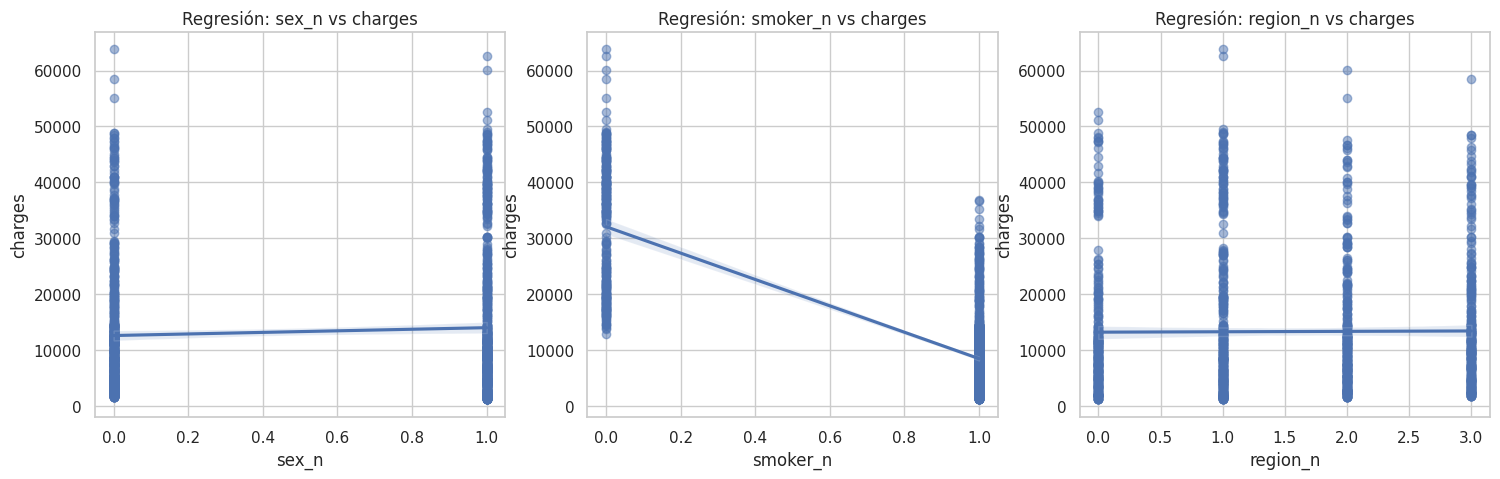

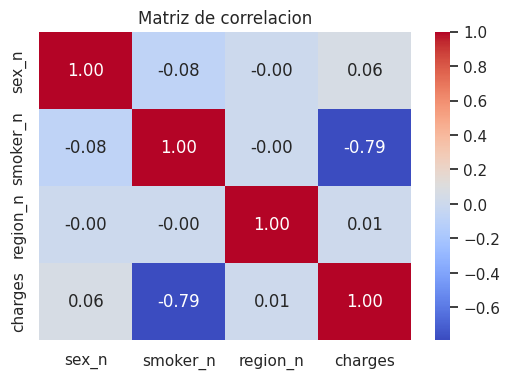

In [13]:

sns.set(style='whitegrid')
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
sns.regplot(x='sex_n', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('Regresión: sex_n vs charges')


plt.subplot(1, 3, 2)
sns.regplot(x='smoker_n', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('Regresión: smoker_n vs charges')

plt.subplot(1, 3, 3)
sns.regplot(x='region_n', y='charges', data=df, scatter_kws={'alpha': 0.5})
plt.title('Regresión: region_n vs charges')

correlation = df[['sex_n', 'smoker_n', 'region_n', 'charges']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlacion')


plt.show()


Tras este analisis podemos considerar que smoker tiene una correlacion del -0,79, que significa esto, que cuando smoker es = 0, es decir que son fumadores, las primas tienden a ser mucho altas.
Consideraremos esta variable como clave a la hora de hacer nuestro modelo de prediccion. La otra variable que puede ser considerada seria age pero tendriamos que quitar muchos outliers debido a que gente muy joven tiene contratados primas mucho mas caras.

## Paso 3 Split


In [14]:
df_train = df
df_test = df

Separar correctamente los datos (train/test split), Codificar variables categoricas con one-hot encoding, Entrenar modelo (ejemplo regresión logística) y Evaluar el modelo

In [35]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,)

In [36]:
categorical_cols = ['sex', 'smoker', 'region']  # ejemplo

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)


X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


In [ ]:


y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.806928708119801
MAE: 4177.045561036318
MSE: 35478020.67523564
RMSE: 5956.342894363591


# PASO 5 PREDICCION DEL MODELO

In [ ]:
X_test

,age,bmi,children,sex_n,smoker_n,region_n
0,19,27.900,0,0,0,0
1,18,33.770,1,1,1,1
2,28,33.000,3,1,1,1
3,33,22.705,0,1,1,2
4,32,28.880,0,1,1,2
...,...,...,...,...,...,...
1333,50,30.970,3,1,1,2
1334,18,31.920,0,0,1,3
1335,18,36.850,0,0,1,1
1336,21,25.800,0,0,1,0


In [ ]:
y_test

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1337, dtype: float64

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([25111.94918534,  3691.31319209,  6964.78975616, ...,
        4366.33721054,  1108.75447502, 37011.63976662], shape=(1337,))

In [42]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),
           'RMSE': root_mean_squared_error(y_test, y_pred),
           'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
           'R^2': r2_score(y_test, y_pred),}

metrics

{'MSE': 35478020.67523564,
 'RMSE': 5956.342894363591,
 'MAPE': 0.41396756371380583,
 'R^2': 0.806928708119801}